# 01. 탐색적 데이터 분석 (EDA)

**Kaggle "Store Sales - Time Series Forecasting"** 데이터의 구조, 분포, 패턴을 탐색한다.

- 데이터: 에콰도르 Favorita 매장 체인의 매출 데이터 (2013~2017)
- 54개 매장 × 33개 상품군 = 1,782개 시계열 중 **Top 5 상품군 × 전체 매장 합산**으로 집중
- 목표: 계절성, 트렌드, 외생변수 효과를 파악하여 모델링 전략 수립

In [1]:
import sys
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings("ignore")

# 한글 폰트 설정 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 프로젝트 루트를 path에 추가
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 시각화 스타일
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

print(f"Project root: {PROJECT_ROOT}")

Project root: E:\프로젝트\부족한 프로젝트 시작\수요예측 시스템


In [2]:
from src.data_loader import load_raw_data

raw = load_raw_data(PROJECT_ROOT / "data" / "raw")

train = raw["train"]
stores = raw["stores"]
oil = raw["oil"]
holidays = raw["holidays"]
transactions = raw["transactions"]

print("=== 데이터 로드 완료 ===")
for name, df in raw.items():
    print(f"{name:15s}: {df.shape[0]:>10,} rows × {df.shape[1]:>3} cols")

=== 데이터 로드 완료 ===
train          :  3,000,888 rows ×   6 cols
stores         :         54 rows ×   5 cols
oil            :      1,218 rows ×   2 cols
holidays       :        350 rows ×   6 cols
transactions   :     83,488 rows ×   3 cols


## 1. 데이터 구조 파악

각 데이터셋의 구조, 크기, 데이터 타입을 확인한다.

In [3]:
print("=== train.csv ===")
display(train.head())
print(f"\n기간: {train['date'].min().date()} ~ {train['date'].max().date()}")
print(f"매장 수: {train['store_nbr'].nunique()}")
print(f"상품군 수: {train['family'].nunique()}")
print("\n상품군 목록:")
for i, fam in enumerate(sorted(train["family"].unique()), 1):
    print(f"  {i:2d}. {fam}")

=== train.csv ===


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0



기간: 2013-01-01 ~ 2017-08-15
매장 수: 54
상품군 수: 33

상품군 목록:
   1. AUTOMOTIVE
   2. BABY CARE
   3. BEAUTY
   4. BEVERAGES
   5. BOOKS
   6. BREAD/BAKERY
   7. CELEBRATION
   8. CLEANING
   9. DAIRY
  10. DELI
  11. EGGS
  12. FROZEN FOODS
  13. GROCERY I
  14. GROCERY II
  15. HARDWARE
  16. HOME AND KITCHEN I
  17. HOME AND KITCHEN II
  18. HOME APPLIANCES
  19. HOME CARE
  20. LADIESWEAR
  21. LAWN AND GARDEN
  22. LINGERIE
  23. LIQUOR,WINE,BEER
  24. MAGAZINES
  25. MEATS
  26. PERSONAL CARE
  27. PET SUPPLIES
  28. PLAYERS AND ELECTRONICS
  29. POULTRY
  30. PREPARED FOODS
  31. PRODUCE
  32. SCHOOL AND OFFICE SUPPLIES
  33. SEAFOOD


In [4]:
print("=== stores.csv ===")
display(stores.head())
print(f"\n매장 타입: {sorted(stores['type'].unique())}")
print(f"도시 수: {stores['city'].nunique()}")
print(f"주(state) 수: {stores['state'].nunique()}")

=== stores.csv ===


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4



매장 타입: ['A', 'B', 'C', 'D', 'E']
도시 수: 22
주(state) 수: 16


In [5]:
print("=== 기초 통계 (sales) ===")
display(train["sales"].describe())
print(f"\n0인 매출 비율: {(train['sales'] == 0).mean() * 100:.1f}%")
print(f"음수 매출 건수: {(train['sales'] < 0).sum()}")

=== 기초 통계 (sales) ===


count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64


0인 매출 비율: 31.3%
음수 매출 건수: 0


### 1.1 결측치 분석

In [6]:
print("=== 결측치 분석 ===\n")
for name, df in raw.items():
    missing = df.isnull().sum()
    if missing.any():
        print(f"[{name}]")
        print(missing[missing > 0])
        print()
    else:
        print(f"[{name}] 결측치 없음\n")

=== 결측치 분석 ===

[train] 결측치 없음

[stores] 결측치 없음

[oil]
dcoilwtico    43
dtype: int64

[holidays] 결측치 없음

[transactions] 결측치 없음



## 2. Top 5 상품군 선정

54개 매장 × 33개 상품군 = 1,782개 시계열을 모두 모델링하는 것은 비효율적이다.
**총 매출 기준 Top 5 상품군**을 선정하고, 전체 매장을 합산하여 **5개 시계열**로 집중한다.

In [7]:
family_sales = train.groupby("family")["sales"].sum().sort_values(ascending=False)
top5 = family_sales.head(5)
top5_families = top5.index.tolist()

print("=== Top 5 상품군 (총 매출 기준) ===")
for i, (fam, sales) in enumerate(top5.items(), 1):
    pct = sales / family_sales.sum() * 100
    print(f"  {i}. {fam}: {sales:,.0f} ({pct:.1f}%)")

print(f"\nTop 5 합산 비중: {top5.sum() / family_sales.sum() * 100:.1f}%")

=== Top 5 상품군 (총 매출 기준) ===
  1. GROCERY I: 343,462,735 (32.0%)
  2. BEVERAGES: 216,954,486 (20.2%)
  3. PRODUCE: 122,704,685 (11.4%)
  4. CLEANING: 97,521,289 (9.1%)
  5. DAIRY: 64,487,709 (6.0%)

Top 5 합산 비중: 78.7%


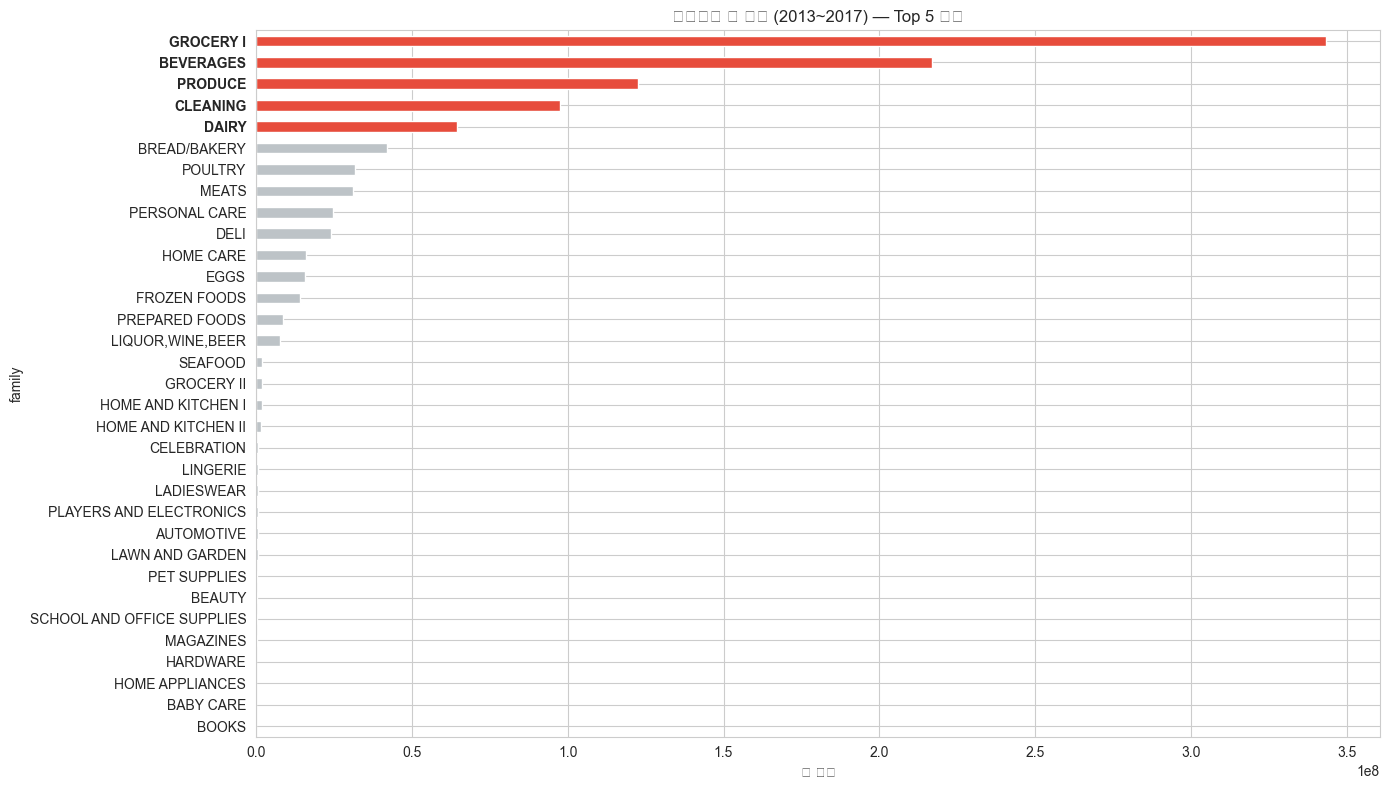

In [8]:
fig, ax = plt.subplots(figsize=(14, 8))
colors = ["#e74c3c" if f in top5_families else "#bdc3c7" for f in family_sales.index]
family_sales.plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("총 매출")
ax.set_title("상품군별 총 매출 (2013~2017) — Top 5 강조")
ax.invert_yaxis()
for i, fam in enumerate(family_sales.index):
    if fam in top5_families:
        ax.get_yticklabels()[i].set_fontweight("bold")
plt.tight_layout()
plt.show()

## 3. 매출 시계열 시각화

전체 매출과 Top 5 상품군별 일별 매출 추이를 시각화한다.

In [9]:
# Top 5 상품군 필터링 + 매장 합산
top5_data = train[train["family"].isin(top5_families)].copy()
daily_by_family = top5_data.groupby(["date", "family"])["sales"].sum().reset_index()

# 전체 매장 합산 총 매출
daily_total = train.groupby("date")["sales"].sum().reset_index()
daily_total.columns = ["date", "total_sales"]

print(f"Top 5 상품군 일별 데이터: {daily_by_family.shape}")
print(f"전체 일별 총매출 데이터: {daily_total.shape}")

Top 5 상품군 일별 데이터: (8420, 3)
전체 일별 총매출 데이터: (1684, 2)


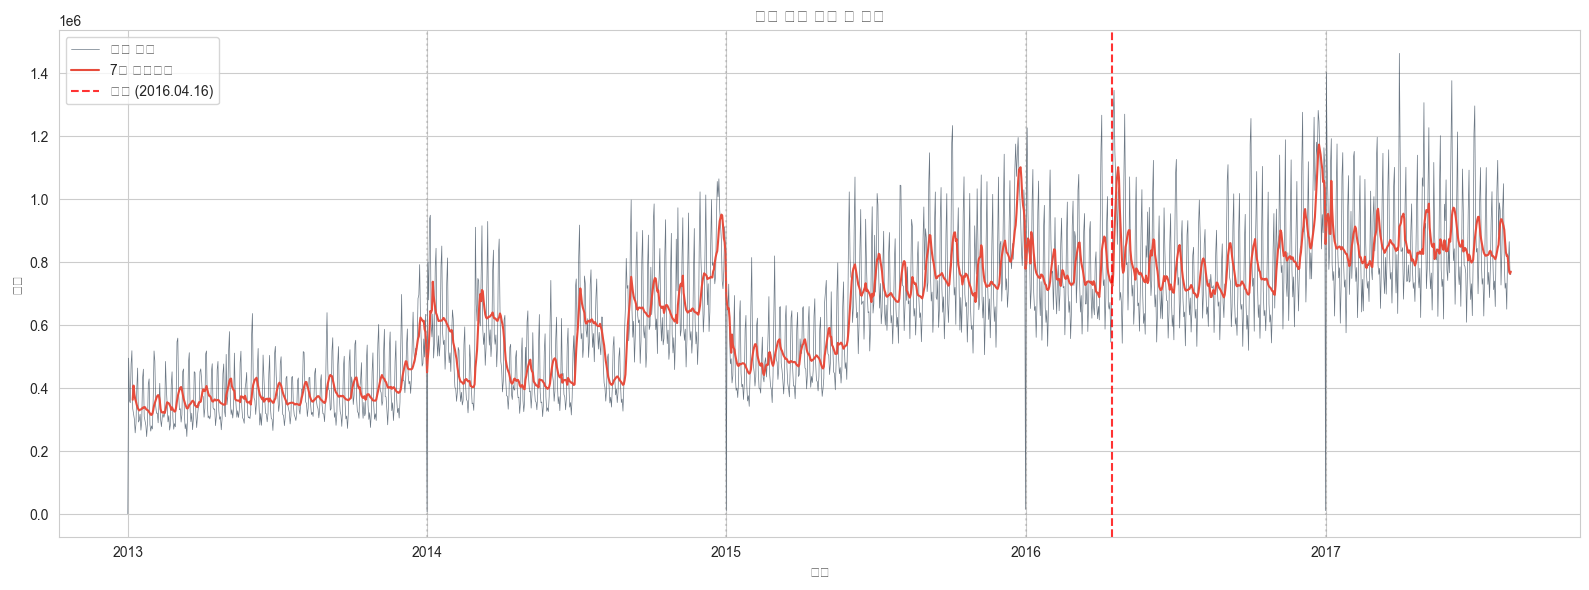

In [10]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(
    daily_total["date"],
    daily_total["total_sales"],
    linewidth=0.5,
    alpha=0.7,
    color="#2c3e50",
    label="일별 매출",
)

# 7일 이동평균
ma7 = daily_total.set_index("date")["total_sales"].rolling(7).mean()
ax.plot(ma7.index, ma7.values, linewidth=1.5, color="#e74c3c", label="7일 이동평균")

# 지진 표시
ax.axvline(
    pd.Timestamp("2016-04-16"),
    color="red",
    linestyle="--",
    alpha=0.8,
    label="지진 (2016.04.16)",
)

# 연도 구분
for year in range(2014, 2018):
    ax.axvline(pd.Timestamp(f"{year}-01-01"), color="gray", linestyle=":", alpha=0.3)

ax.set_title("전체 매장 일별 총 매출")
ax.set_xlabel("날짜")
ax.set_ylabel("매출")
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

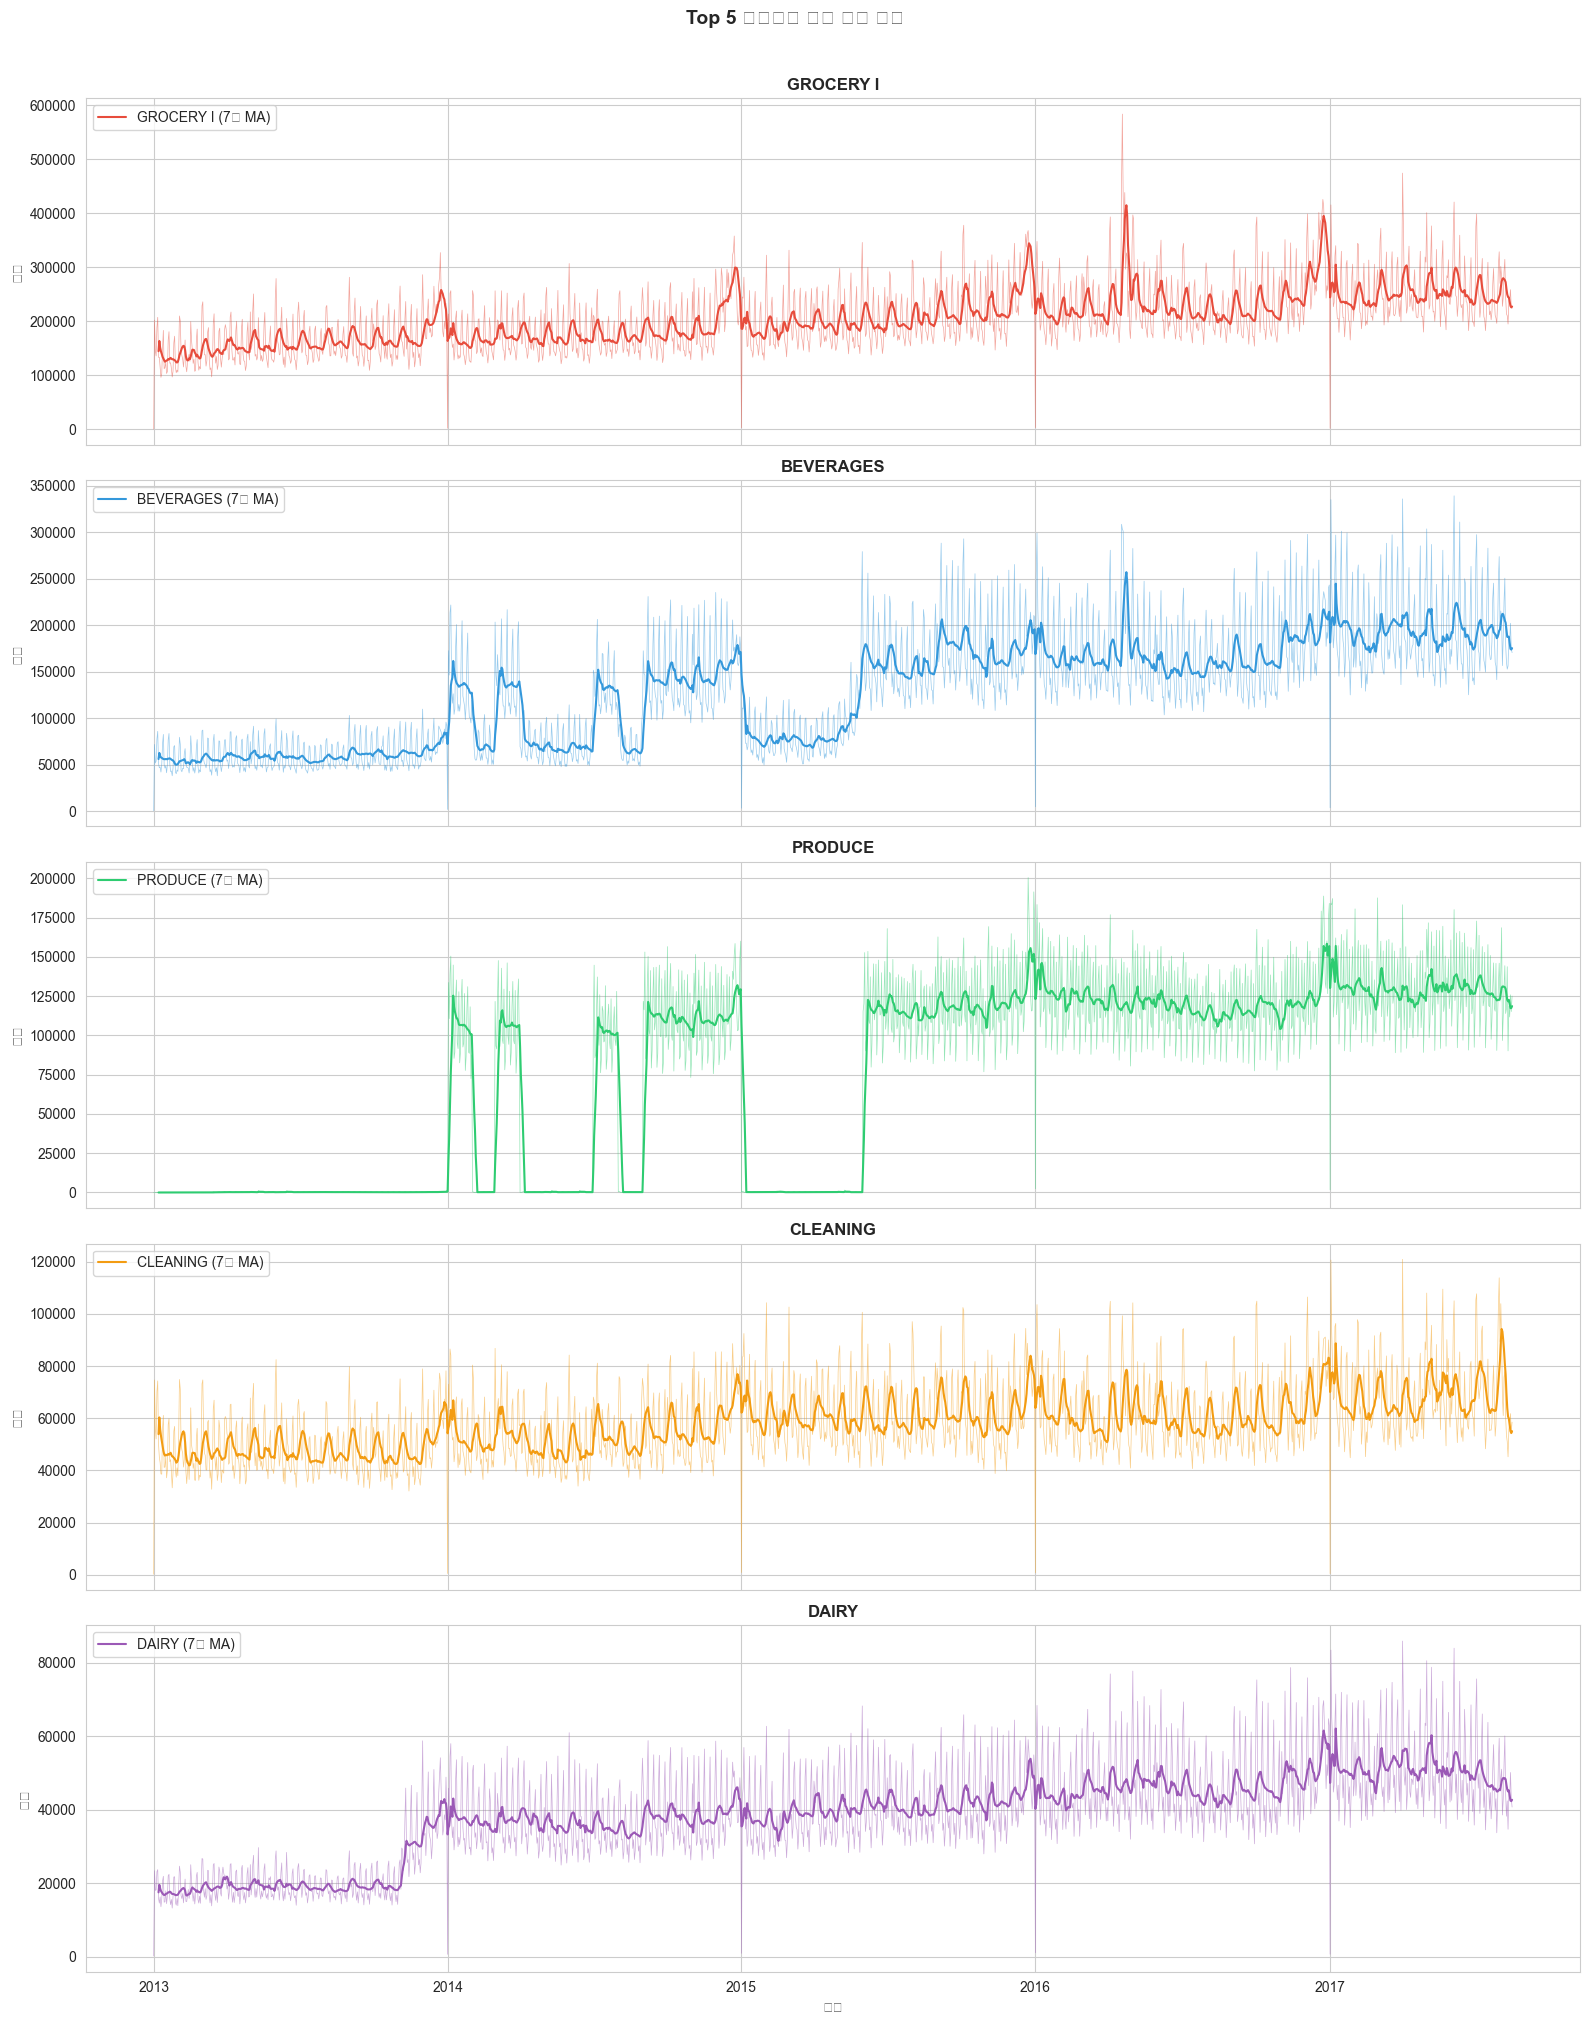

In [11]:
colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]

fig, axes = plt.subplots(
    len(top5_families), 1, figsize=(16, 4 * len(top5_families)), sharex=True
)

for idx, (fam, color) in enumerate(zip(top5_families, colors)):
    ax = axes[idx]
    fam_data = daily_by_family[daily_by_family["family"] == fam]
    ax.plot(fam_data["date"], fam_data["sales"], linewidth=0.5, alpha=0.5, color=color)

    # 7일 이동평균
    ma = fam_data.set_index("date")["sales"].rolling(7).mean()
    ax.plot(ma.index, ma.values, linewidth=1.5, color=color, label=f"{fam} (7일 MA)")

    ax.set_ylabel("매출")
    ax.set_title(fam, fontsize=12, fontweight="bold")
    ax.legend(loc="upper left")

axes[-1].set_xlabel("날짜")
plt.suptitle("Top 5 상품군별 일별 매출 추이", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 4. 계절성 패턴 분석

요일별, 월별, 연도별 매출 패턴을 분석하여 계절성 구조를 파악한다.

### 4.1 요일별 패턴

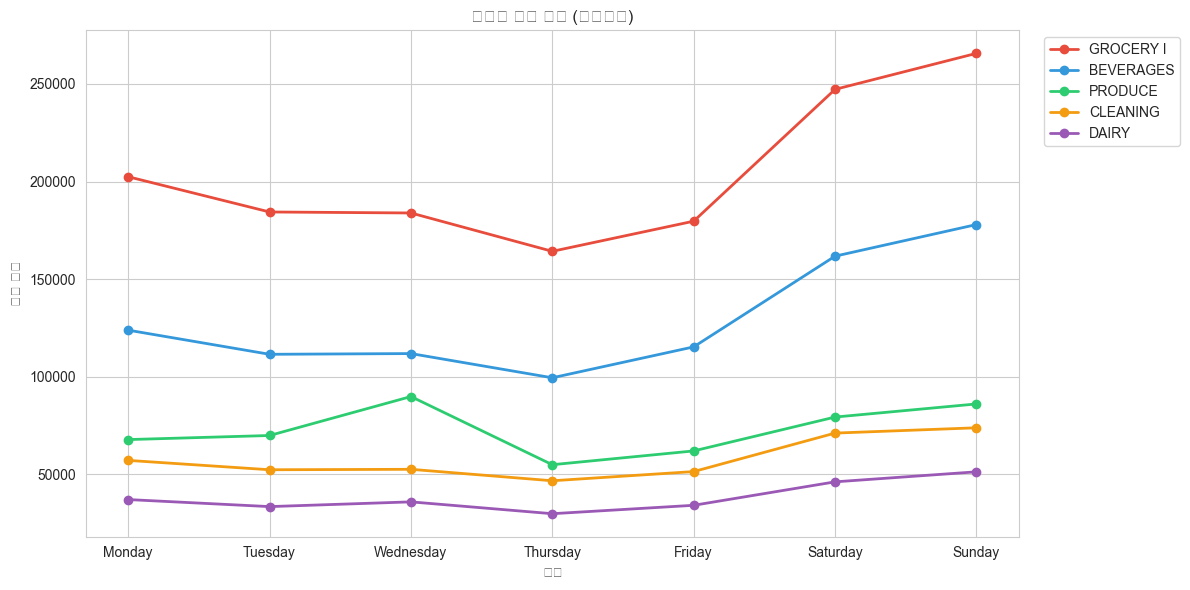

In [12]:
top5_data_dt = top5_data.copy()
top5_data_dt["day_of_week"] = top5_data_dt["date"].dt.dayofweek
top5_data_dt["day_name"] = top5_data_dt["date"].dt.day_name()

# 상품군 x 요일별 평균 매출 (매장 합산 후 평균)
dow_agg = (
    top5_data_dt.groupby(["date", "family", "day_of_week", "day_name"])["sales"]
    .sum()  # 같은 날 같은 family의 전 매장 합산
    .reset_index()
)
dow_sales = (
    dow_agg.groupby(["family", "day_of_week", "day_name"])["sales"].mean().reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

for fam, color in zip(top5_families, colors):
    fam_dow = dow_sales[dow_sales["family"] == fam].sort_values("day_of_week")
    ax.plot(
        fam_dow["day_name"],
        fam_dow["sales"],
        marker="o",
        linewidth=2,
        label=fam,
        color=color,
    )

ax.set_title("요일별 평균 매출 (상품군별)")
ax.set_xlabel("요일")
ax.set_ylabel("평균 매출")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 4.2 월별 패턴

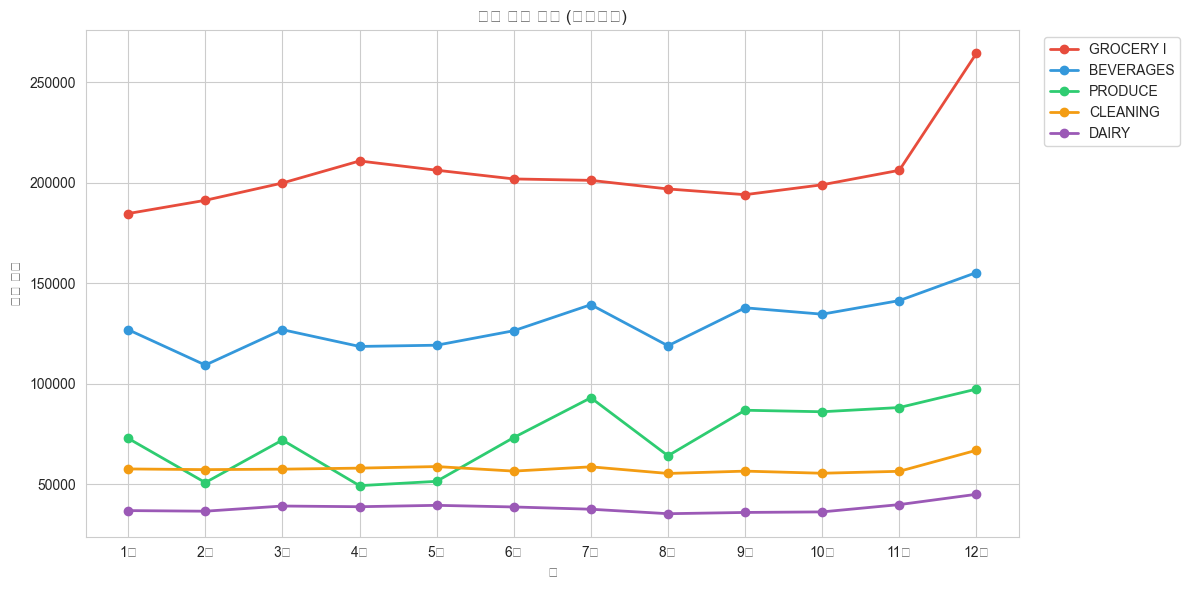

In [13]:
top5_data_dt["month"] = top5_data_dt["date"].dt.month

month_agg = (
    top5_data_dt.groupby(["date", "family", "month"])["sales"].sum().reset_index()
)
month_sales = month_agg.groupby(["family", "month"])["sales"].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
for fam, color in zip(top5_families, colors):
    fam_month = month_sales[month_sales["family"] == fam]
    ax.plot(
        fam_month["month"],
        fam_month["sales"],
        marker="o",
        linewidth=2,
        label=fam,
        color=color,
    )

ax.set_title("월별 평균 매출 (상품군별)")
ax.set_xlabel("월")
ax.set_ylabel("평균 매출")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(
    [
        "1월",
        "2월",
        "3월",
        "4월",
        "5월",
        "6월",
        "7월",
        "8월",
        "9월",
        "10월",
        "11월",
        "12월",
    ]
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 4.3 연도별 패턴 비교

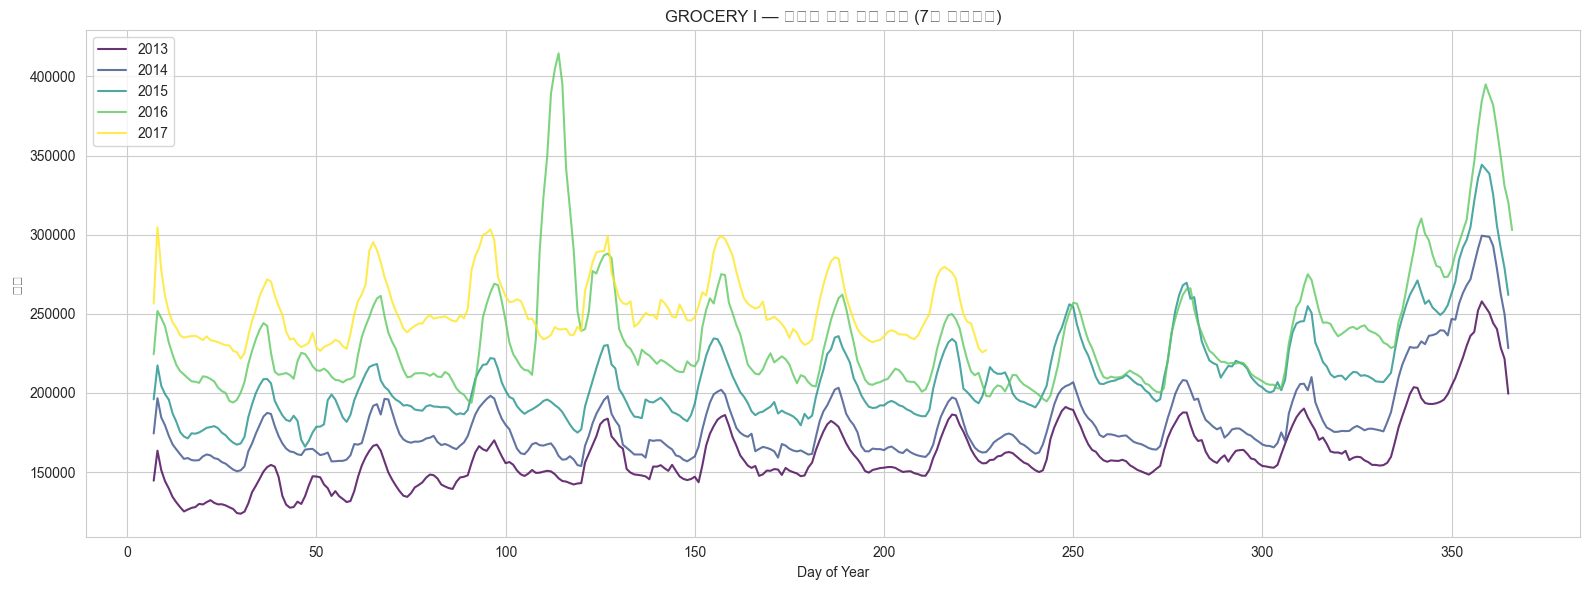

In [14]:
top5_data_dt["year"] = top5_data_dt["date"].dt.year
top5_data_dt["day_of_year"] = top5_data_dt["date"].dt.dayofyear

# Top 1 상품군으로 연도별 비교
top1_fam = top5_families[0]
grocery = top5_data_dt[top5_data_dt["family"] == top1_fam]
yearly = grocery.groupby(["year", "day_of_year"])["sales"].sum().reset_index()

fig, ax = plt.subplots(figsize=(16, 6))
year_colors = plt.cm.viridis(np.linspace(0, 1, yearly["year"].nunique()))

for (year, group), color in zip(yearly.groupby("year"), year_colors):
    ma = group.set_index("day_of_year")["sales"].rolling(7).mean()
    ax.plot(ma.index, ma.values, label=str(year), linewidth=1.5, color=color, alpha=0.8)

ax.set_title(f"{top1_fam} — 연도별 매출 패턴 비교 (7일 이동평균)")
ax.set_xlabel("Day of Year")
ax.set_ylabel("매출")
ax.legend()
plt.tight_layout()
plt.show()

## 5. 프로모션 효과 분석

프로모션 유무에 따른 매출 차이를 상품군별로 비교한다.

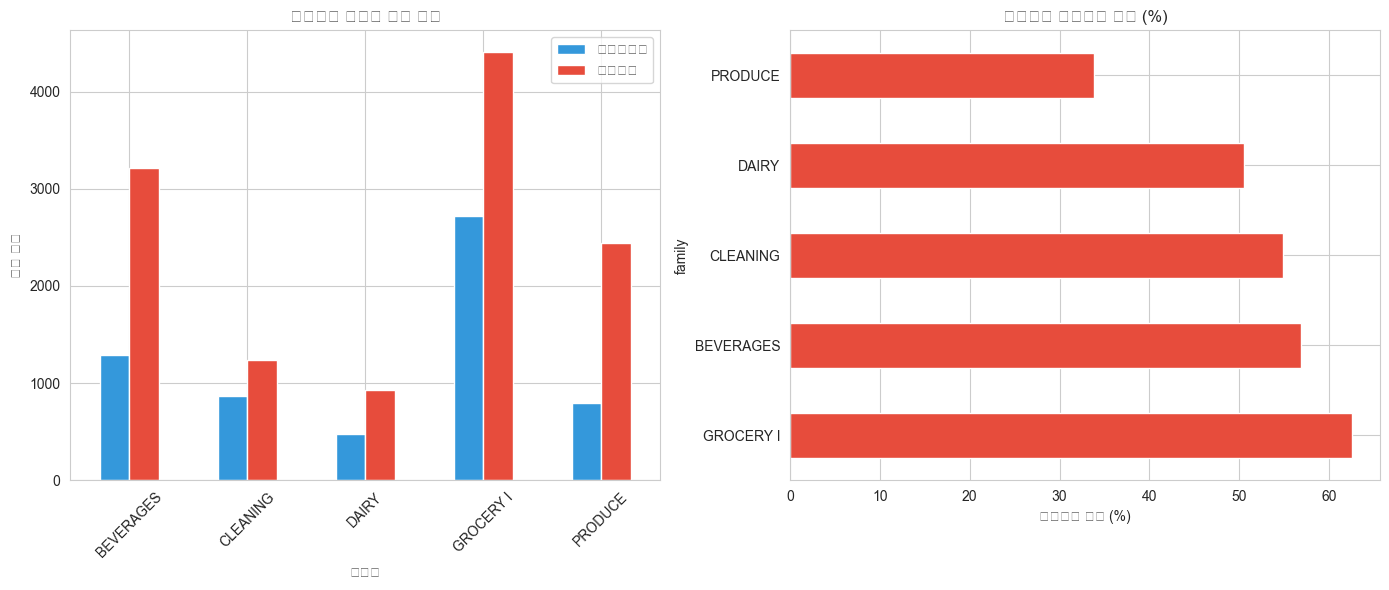

=== 프로모션 효과 (평균 매출 증가율) ===
  GROCERY I: +62.3%
  BEVERAGES: +148.8%
  PRODUCE: +207.8%
  CLEANING: +42.8%
  DAIRY: +94.5%


In [15]:
promo_comparison = (
    top5_data.assign(
        promo_flag=lambda x: (x["onpromotion"] > 0).map(
            {True: "프로모션", False: "비프로모션"}
        )
    )
    .groupby(["family", "promo_flag"])["sales"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (1) 평균 매출 비교
promo_pivot = promo_comparison.pivot(
    index="family", columns="promo_flag", values="mean"
)
promo_pivot.plot(kind="bar", ax=axes[0], color=["#3498db", "#e74c3c"])
axes[0].set_title("프로모션 유무별 평균 매출")
axes[0].set_xlabel("상품군")
axes[0].set_ylabel("평균 매출")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="")

# (2) 프로모션 비율
promo_ratio = (
    top5_data.groupby("family")
    .apply(lambda x: (x["onpromotion"] > 0).mean() * 100)
    .sort_values(ascending=False)
)
promo_ratio.plot(kind="barh", ax=axes[1], color="#e74c3c")
axes[1].set_title("상품군별 프로모션 비율 (%)")
axes[1].set_xlabel("프로모션 비율 (%)")

plt.tight_layout()
plt.show()

# 프로모션 효과 수치
print("=== 프로모션 효과 (평균 매출 증가율) ===")
for fam in top5_families:
    fam_data = promo_comparison[promo_comparison["family"] == fam]
    promo_mean = fam_data[fam_data["promo_flag"] == "프로모션"]["mean"].values
    no_promo_mean = fam_data[fam_data["promo_flag"] == "비프로모션"]["mean"].values
    if len(promo_mean) > 0 and len(no_promo_mean) > 0 and no_promo_mean[0] > 0:
        lift = (promo_mean[0] - no_promo_mean[0]) / no_promo_mean[0] * 100
        print(f"  {fam}: {lift:+.1f}%")

## 6. 이상치 분석 — 2016년 에콰도르 지진

2016년 4월 16일 에콰도르에서 규모 7.8 지진이 발생했다.
지진 전후 매출 변화를 분석하여 모델링 시 고려 사항을 파악한다.

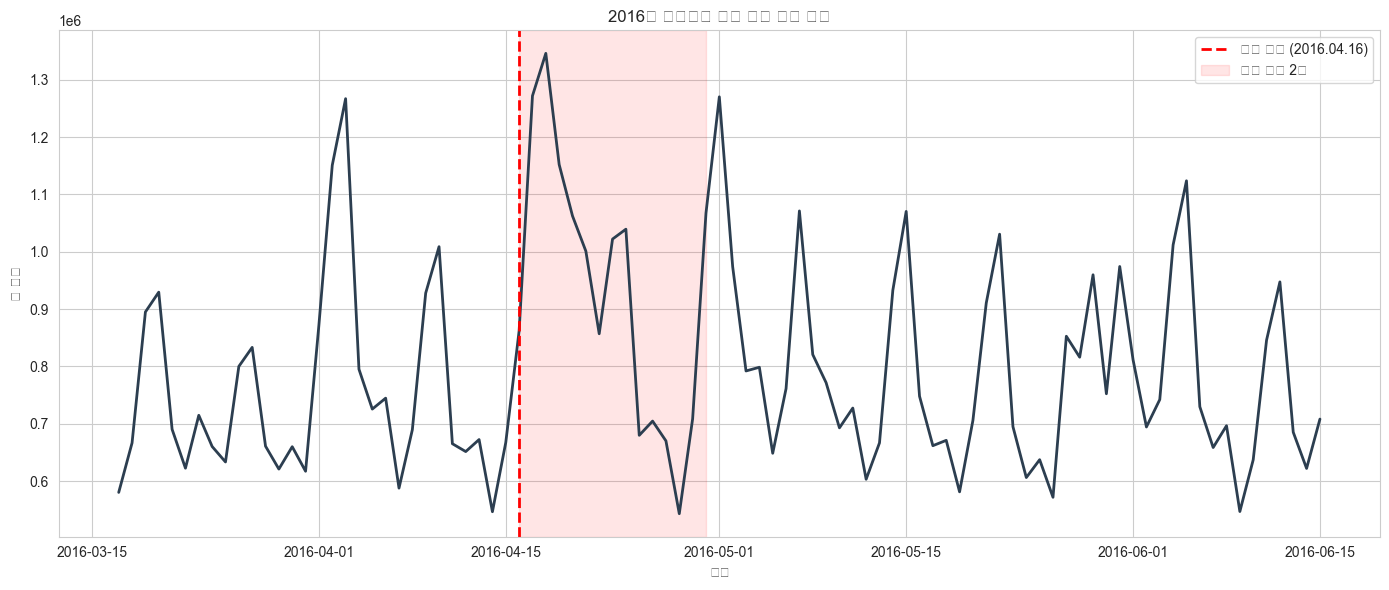

지진 전 30일 평균 매출: 752,054
지진 후 30일 평균 매출: 882,579
변화율: +17.4%


In [16]:
earthquake_date = pd.Timestamp("2016-04-16")
window_start = earthquake_date - pd.Timedelta(days=30)
window_end = earthquake_date + pd.Timedelta(days=60)

eq_data = daily_total[
    (daily_total["date"] >= window_start) & (daily_total["date"] <= window_end)
]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(eq_data["date"], eq_data["total_sales"], linewidth=2, color="#2c3e50")
ax.axvline(
    earthquake_date,
    color="red",
    linestyle="--",
    linewidth=2,
    label="지진 발생 (2016.04.16)",
)
ax.axvspan(
    earthquake_date,
    earthquake_date + pd.Timedelta(days=14),
    alpha=0.1,
    color="red",
    label="지진 직후 2주",
)

ax.set_title("2016년 에콰도르 지진 전후 매출 변화")
ax.set_xlabel("날짜")
ax.set_ylabel("총 매출")
ax.legend()
plt.tight_layout()
plt.show()

# 지진 전후 통계
before = daily_total[
    (daily_total["date"] >= earthquake_date - pd.Timedelta(days=30))
    & (daily_total["date"] < earthquake_date)
]["total_sales"]
after = daily_total[
    (daily_total["date"] > earthquake_date)
    & (daily_total["date"] <= earthquake_date + pd.Timedelta(days=30))
]["total_sales"]

print(f"지진 전 30일 평균 매출: {before.mean():,.0f}")
print(f"지진 후 30일 평균 매출: {after.mean():,.0f}")
print(f"변화율: {(after.mean() - before.mean()) / before.mean() * 100:+.1f}%")

## 7. 외생변수: 유가 (Oil Price)

에콰도르는 석유 수출 의존 경제이므로 유가와 매출의 관계를 분석한다.
유가 데이터에는 결측치가 많으므로 선형 보간 후 분석한다.

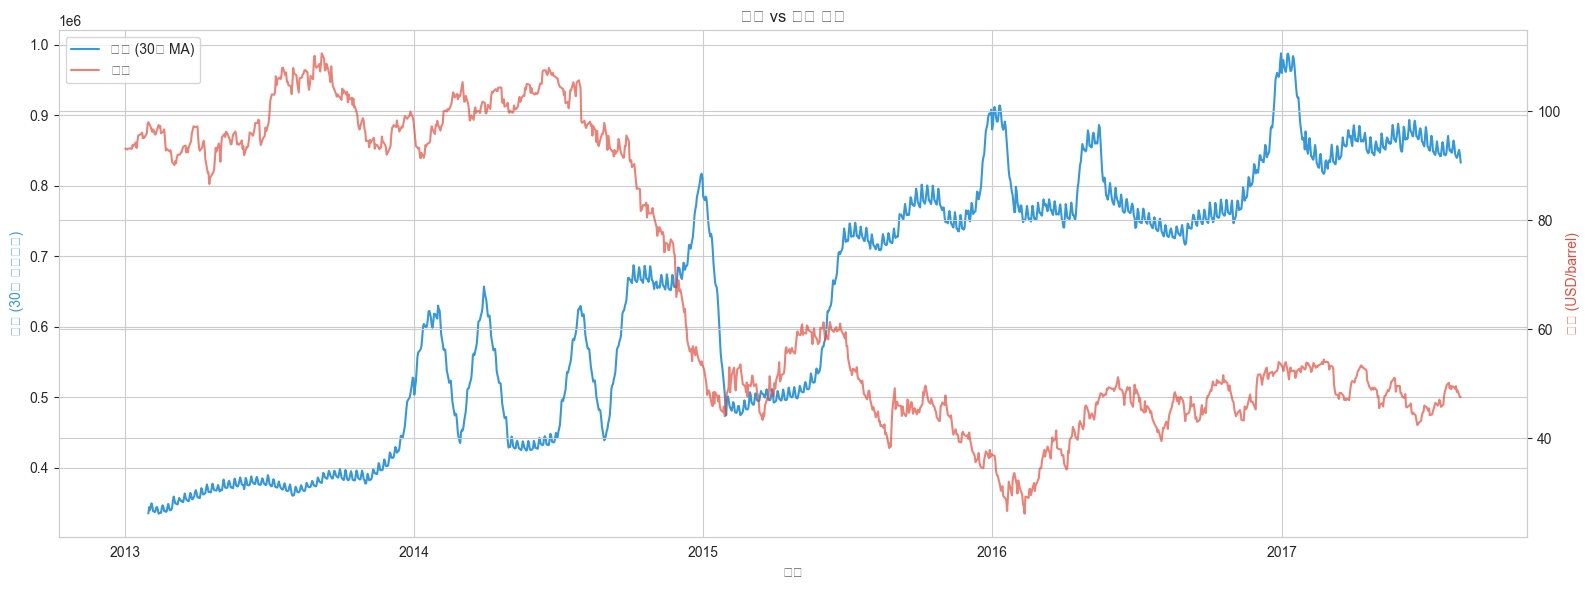

유가-매출 피어슨 상관계수: -0.628


In [17]:
oil_clean = oil.copy()
oil_clean = oil_clean.rename(columns={"dcoilwtico": "oil_price"})
oil_clean["oil_price"] = (
    oil_clean["oil_price"].interpolate(method="linear").ffill().bfill()
)

# 유가 + 총매출 비교
merged = daily_total.merge(oil_clean, on="date", how="left")
merged["oil_price"] = merged["oil_price"].interpolate().ffill().bfill()

fig, ax1 = plt.subplots(figsize=(16, 6))
ax2 = ax1.twinx()

ax1.plot(
    merged["date"],
    merged["total_sales"].rolling(30).mean(),
    color="#3498db",
    linewidth=1.5,
    label="매출 (30일 MA)",
)
ax2.plot(
    merged["date"],
    merged["oil_price"],
    color="#e74c3c",
    linewidth=1.5,
    alpha=0.7,
    label="유가",
)

ax1.set_xlabel("날짜")
ax1.set_ylabel("매출 (30일 이동평균)", color="#3498db")
ax2.set_ylabel("유가 (USD/barrel)", color="#e74c3c")
ax1.set_title("유가 vs 매출 추이")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

# 상관계수
corr = merged[["total_sales", "oil_price"]].dropna().corr()
print(f"유가-매출 피어슨 상관계수: {corr.loc['total_sales', 'oil_price']:.3f}")

## 8. 외생변수: 거래 건수 (Transactions)

일별 거래 건수와 매출의 관계를 분석한다.

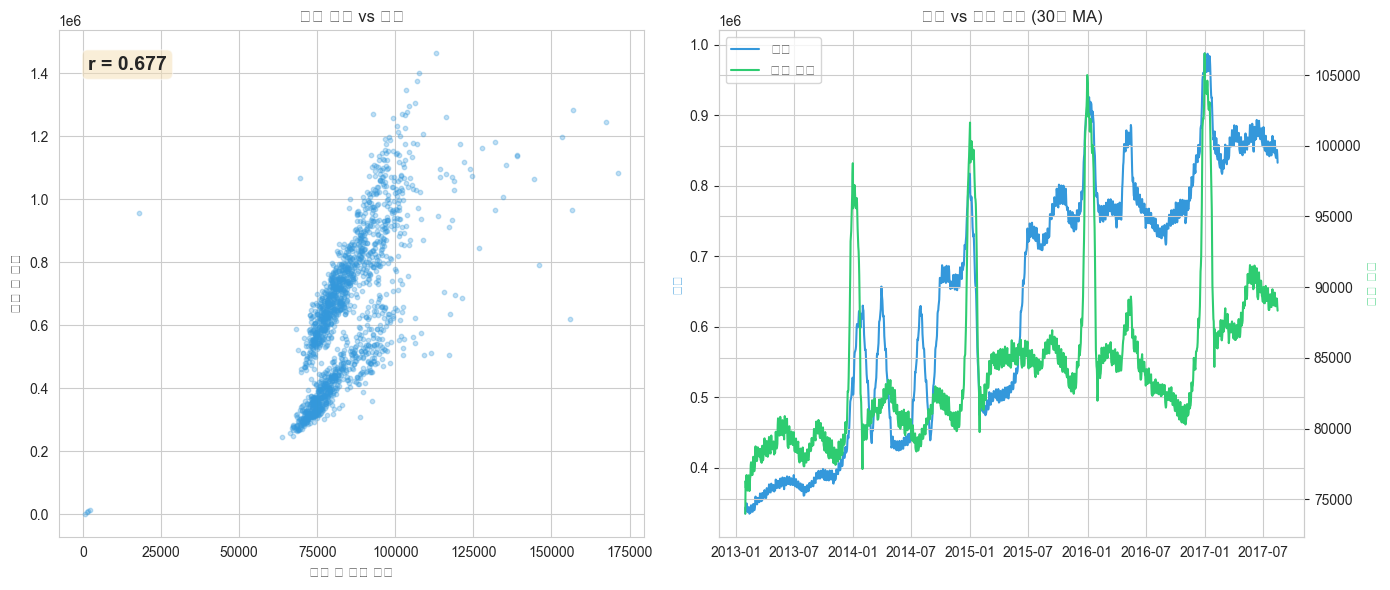

In [18]:
trans_daily = transactions.groupby("date")["transactions"].sum().reset_index()
trans_daily.columns = ["date", "total_transactions"]
merged_trans = daily_total.merge(trans_daily, on="date", how="inner")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (1) 산점도
axes[0].scatter(
    merged_trans["total_transactions"],
    merged_trans["total_sales"],
    alpha=0.3,
    s=10,
    color="#3498db",
)
axes[0].set_xlabel("일별 총 거래 건수")
axes[0].set_ylabel("일별 총 매출")
axes[0].set_title("거래 건수 vs 매출")

corr_val = merged_trans[["total_transactions", "total_sales"]].corr().iloc[0, 1]
axes[0].text(
    0.05,
    0.95,
    f"r = {corr_val:.3f}",
    transform=axes[0].transAxes,
    fontsize=14,
    verticalalignment="top",
    fontweight="bold",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)

# (2) 시계열 비교
ax_t1 = axes[1]
ax_t2 = ax_t1.twinx()
ax_t1.plot(
    merged_trans["date"],
    merged_trans["total_sales"].rolling(30).mean(),
    color="#3498db",
    label="매출",
)
ax_t2.plot(
    merged_trans["date"],
    merged_trans["total_transactions"].rolling(30).mean(),
    color="#2ecc71",
    label="거래 건수",
)
ax_t1.set_title("매출 vs 거래 건수 (30일 MA)")
ax_t1.set_ylabel("매출", color="#3498db")
ax_t2.set_ylabel("거래 건수", color="#2ecc71")

lines1, labels1 = ax_t1.get_legend_handles_labels()
lines2, labels2 = ax_t2.get_legend_handles_labels()
ax_t1.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.show()

## 9. 상관관계 분석

전처리된 전체 데이터의 변수 간 상관관계를 히트맵으로 시각화한다.

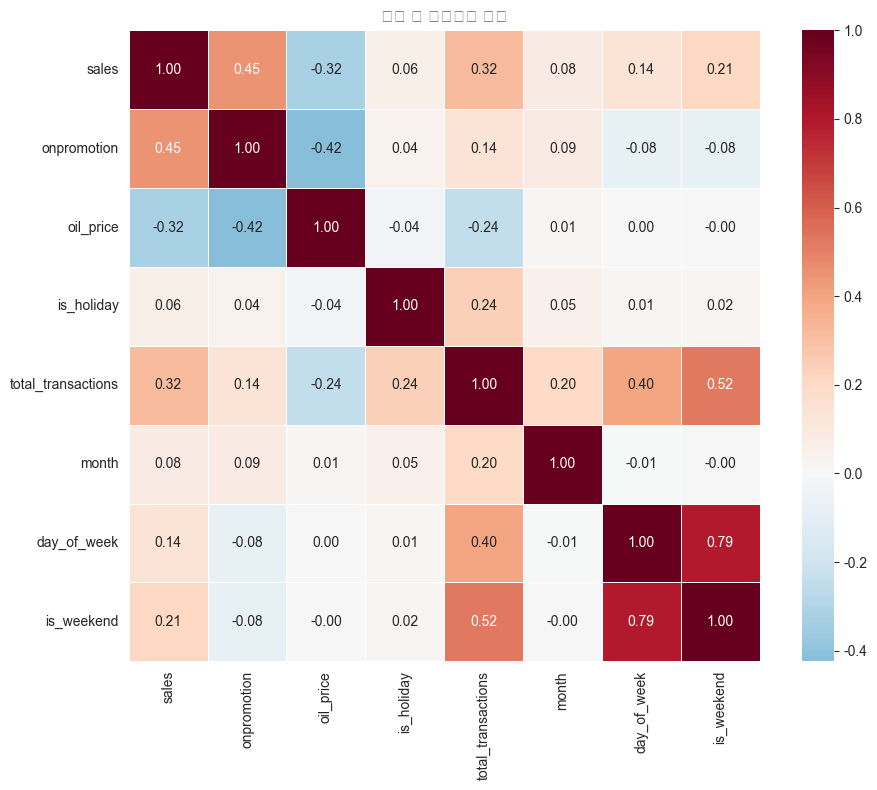

In [19]:
from src.data_loader import (
    aggregate_by_family,
    prepare_oil_data,
    prepare_holidays,
    aggregate_transactions,
    merge_external_data,
    create_date_features,
)

agg = aggregate_by_family(train, top5_families)
date_range = pd.date_range(agg["date"].min(), agg["date"].max(), freq="D")
oil_proc = prepare_oil_data(oil, date_range)
holidays_proc = prepare_holidays(holidays)
trans_proc = aggregate_transactions(transactions)

full = merge_external_data(agg, oil_proc, holidays_proc, trans_proc)
full = create_date_features(full)

# 숫자 컬럼만 상관관계
numeric_cols = [
    "sales",
    "onpromotion",
    "oil_price",
    "is_holiday",
    "total_transactions",
    "month",
    "day_of_week",
    "is_weekend",
]
corr_matrix = full[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("변수 간 상관관계 행렬")
plt.tight_layout()
plt.show()

## 10. 핵심 발견 요약

### 데이터 구조
- 54개 매장 × 33개 상품군, 2013~2017년 일별 데이터 (~300만 행)
- **Top 5 상품군**이 전체 매출의 상당 부분 차지 → 이 5개로 집중 분석
- 유가 데이터에 결측치 존재 → 선형 보간으로 처리

### 계절성 패턴
- **요일 효과**: 주말(특히 일요일) 매출 패턴이 상품군마다 다름
- **월별 효과**: 12월 연말 시즌 매출 급등, 1~2월 상대적 저조
- **연간 트렌드**: 전반적으로 상승 추세

### 외생변수
- **유가**: 에콰도르 경제 특성상 유가와 매출의 관계 존재
- **거래 건수**: 매출과 강한 양의 상관관계 → 유용한 피처
- **프로모션**: 프로모션 시 매출 증가 효과 확인, 상품군별 차이 존재

### 특수 이벤트
- **2016.04.16 지진**: 직후 매출 급변 → 모델링 시 더미 변수 또는 별도 처리 필요

### 모델링 시사점
1. **요일, 월별 계절성** → SARIMA seasonal order, Prophet seasonality 반영
2. **외생변수** (유가, 공휴일, 프로모션, 거래건수) → 모든 모델에 포함
3. **지진 이상치** → 더미 변수 또는 Prophet changepoint로 처리
4. **상품군별 패턴 차이** → 개별 모델 학습
5. **상승 트렌드** → 차분 또는 trend 모델 필요

## 11. 전처리 파이프라인 실행

`src/data_loader.py`의 파이프라인을 실행하여 전처리된 데이터를 저장한다.

In [20]:
from src.data_loader import run_pipeline

result = run_pipeline(top_n=5, save=True)

print("\n=== 최종 데이터 확인 ===")
print(f"Top 5 상품군: {result['top_families']}")
print(f"전체 데이터: {result['full'].shape}")
print(f"Train: {result['train'].shape}")
print(f"Val:   {result['val'].shape}")
print(f"Test:  {result['test'].shape}")

display(result["full"].head(10))

수요예측 데이터 전처리 파이프라인

[1/7] 원본 데이터 로드...


  train: (3000888, 6)
  stores: (54, 5)
  oil: (1218, 2)
  holidays: (350, 6)
  transactions: (83488, 3)

[2/7] Top 5 상품군 선정...
  선정: ['GROCERY I', 'BEVERAGES', 'PRODUCE', 'CLEANING', 'DAIRY']

[3/7] 상품군별 매장 합산...
  결과: (8420, 4)

[4/7] 외생변수 전처리...
  유가: (1688, 2), 공휴일: (160, 3), 거래: (1682, 2)

[5/7] 외생변수 병합...
  결과: (8420, 8)

[6/7] 날짜 피처 생성...
  컬럼: ['date', 'family', 'sales', 'onpromotion', 'oil_price', 'is_holiday', 'holiday_type', 'total_transactions', 'year', 'month', 'day', 'day_of_week', 'day_name', 'week_of_year', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'day_of_year']

[7/7] 시간 기준 분할...
  Train: (7285, 19) (2013-01-01 00:00:00 ~ 2016-12-31 00:00:00)
  Val:   (905, 19) (2017-01-01 00:00:00 ~ 2017-06-30 00:00:00)
  Test:  (230, 19) (2017-07-01 00:00:00 ~ 2017-08-15 00:00:00)



저장 완료: E:\프로젝트\부족한 프로젝트 시작\수요예측 시스템\data\processed

파이프라인 완료!

=== 최종 데이터 확인 ===
Top 5 상품군: ['GROCERY I', 'BEVERAGES', 'PRODUCE', 'CLEANING', 'DAIRY']
전체 데이터: (8420, 19)
Train: (7285, 19)
Val:   (905, 19)
Test:  (230, 19)


,date,family,sales,onpromotion,oil_price,is_holiday,holiday_type,total_transactions,year,month,day,day_of_week,day_name,week_of_year,quarter,is_weekend,is_month_start,is_month_end,day_of_year
0,2013-01-01,BEVERAGES,810.0,0,93.140000,1,Holiday,770.0,2013,1,1,1,Tuesday,1,1,0,1,0,1
1,2013-01-02,BEVERAGES,72092.0,0,93.140000,0,None,93215.0,2013,1,2,2,Wednesday,1,1,0,0,0,2
2,2013-01-03,BEVERAGES,52105.0,0,92.970000,0,None,78504.0,2013,1,3,3,Thursday,1,1,0,0,0,3
3,2013-01-04,BEVERAGES,54167.0,0,93.120000,0,None,78494.0,2013,1,4,4,Friday,1,1,0,0,0,4
4,2013-01-05,BEVERAGES,77818.0,0,93.146667,1,Work Day,93573.0,2013,1,5,5,Saturday,1,1,1,0,0,5
5,2013-01-06,BEVERAGES,86184.0,0,93.173333,0,None,90464.0,2013,1,6,6,Sunday,1,1,1,0,0,6
6,2013-01-07,BEVERAGES,51619.0,0,93.200000,0,None,75597.0,2013,1,7,0,Monday,2,1,0,0,0,7
7,2013-01-08,BEVERAGES,46941.0,0,93.210000,0,None,72325.0,2013,1,8,1,Tuesday,2,1,0,0,0,8
8,2013-01-09,BEVERAGES,47910.0,0,93.080000,0,None,71971.0,2013,1,9,2,Wednesday,2,1,0,0,0,9
9,2013-01-10,BEVERAGES,42390.0,0,93.810000,0,None,66383.0,2013,1,10,3,Thursday,2,1,0,0,0,10
